<a href="https://colab.research.google.com/github/KurniaYufi/nlp-sentiment-analisis/blob/main/TF-IDF%20Homework/1A_TFIDF_Danantara.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Dependencies

In [1]:
import nltk
import math
import matplotlib.pyplot as plt
import pandas as pd
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('punkt')
nltk.download('punkt_tab')

!pip install Sastrawi -q
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 2.4 MB/s eta 0:00:00


# Define Document

In [2]:
sentence2 = """Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar. Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.

Pemerintah Republik Indonesia dan Pemerintah Qatar menggelar diskusi untuk menyepakati kemitraan strategis (co-partnership) dalam pengelolaan dana investasi untuk Indonesia yang akan berfokus di berbagai sektor pembangunan.

Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar. Dana ini akan difokuskan pada pengembangan berbagai sektor di antaranya termasuk tapi tidak terbatas pada hilirisasi industri, energi terbarukan, dan fasilitas kesehatan di Indonesia.

"Kami menyambut baik kepercayaan yang diberikan oleh Pemerintah Qatar melalui pembentukan dana bersama ini," kata CEO Danantara Indonesia Rosan Perkasa Roeslani dalam keterangan tertulis, Selasa, 15 April 2025.

Presiden Prabowo menyampaikan masing-masing negara akan berkontribusi sebesar USD2 miliar dalam dana tersebut. Dana itu akan dikelola oleh BPI Danantara bersama dengan Qatar Investment Authority (QIA) dalam co-partnership.

Dana tersebut akan difokuskan pada peluang investasi di berbagai sektor strategis, antara lain hilirisasi, kesehatan, energi terbarukan, teknologi, serta sektor-sektor lain yang dipandang relevan oleh pengelola dana.

"Danantara Indonesia siap menjalankan mandat tersebut dengan menerapkan tata kelola investasi yang prudent, transparan, dan berorientasi pada hasil. Fokus kami adalah memastikan bahwa setiap proyek yang didanai memberikan dampak strategis dan berkelanjutan bagi perekonomian nasional," ujar Rosan.

Lebih lanjut, Rosan menegaskan, kolaborasi ini menjadi bukti kepercayaan dunia internasional terhadap kapasitas kelembagaan Indonesia dalam mengelola investasi berskala besar.

"Kemitraan ini merupakan langkah konkret dalam membangun kepercayaan dengan mitra global strategis seperti Qatar. Ini menunjukkan bahwa Indonesia tidak hanya menjadi tujuan investasi, tetapi juga memiliki kapasitas kelembagaan yang mumpuni untuk mengelola investasi secara profesional dan akuntabel," ungkapnya.

Inisiatif co-partnership dan perluasan kerja sama strategis ini diharapkan tidak hanya memperkuat hubungan diplomatik kedua negara, tetapi juga memberikan kontribusi nyata terhadap percepatan pembangunan ekonomi dan peningkatan kesejahteraan masyarakat Indonesia."""

# Text Preprocessing

In [3]:
# Sentence tokenization
sent_token = sent_tokenize(sentence2)
print(sent_token)

['Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar.', 'Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.', 'Pemerintah Republik Indonesia dan Pemerintah Qatar menggelar diskusi untuk menyepakati kemitraan strategis (co-partnership) dalam pengelolaan dana investasi untuk Indonesia yang akan berfokus di berbagai sektor pembangunan.', 'Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar.', 'Dana ini akan difokuskan pada pengembangan berbagai sektor di antaranya termasuk tapi tidak terbatas pada hilirisasi industri, energi terbarukan, dan fasilitas kesehatan di Indonesia.', '"Kami menyambut baik kepercayaan yang diberikan oleh Pemerintah Qatar melalui pembentukan dana bersama ini," kata CEO Danantara Indonesia Rosan Perkasa Roeslani dalam keterangan tertulis, Selasa, 15 April 20

In [4]:
# Remove Indonesian stop words using Sastrawi
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

cleaned_sentences = [stopword_remover.remove(sent) for sent in sent_token]

# Training TF-IDF Vectorizer on cleaned sentences
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)
feature_names = vectorizer.get_feature_names_out()

print("Shape of the Feature Matrix (sentences, unique words):", features.shape)
print("\nFeature Names (vocabulary after Indonesian stop word removal):")
print(feature_names)

Shape of the Feature Matrix (sentences, unique words): (15, 162)

Feature Names (vocabulary after Indonesian stop word removal):
['15' '2025' 'adalah' 'akan' 'akuntabel' 'anagata' 'antaranya' 'april'
 'authority' 'badan' 'baik' 'berbagai' 'berfokus' 'berkelanjutan'
 'berkontribusi' 'berorientasi' 'bersama' 'berskala' 'besar' 'bpi' 'buah'
 'bukti' 'ceo' 'co' 'dampak' 'dana' 'danantara' 'daya' 'diberikan'
 'didanai' 'difokuskan' 'diharapkan' 'dikelola' 'dipandang' 'diplomatik'
 'disepakati' 'diskusi' 'doha' 'dunia' 'ekonomi' 'energi' 'fasilitas'
 'fokus' 'global' 'hanya' 'hasil' 'hilirisasi' 'hubungan' 'indonesia'
 'industri' 'ini' 'inisiatif' 'internasional' 'investasi' 'investment'
 'jakarta' 'juga' 'kami' 'kapasitas' 'kata' 'kedua' 'kelembagaan' 'kelola'
 'kemitraan' 'kepercayaan' 'kerja' 'kesehatan' 'kesejahteraan'
 'kesepakatan' 'keterangan' 'kolaborasi' 'konkret' 'kontribusi'
 'kunjungan' 'lain' 'langkah' 'lanjut' 'lebih' 'mandat' 'masing'
 'masyarakat' 'melalui' 'memastikan' 'memb

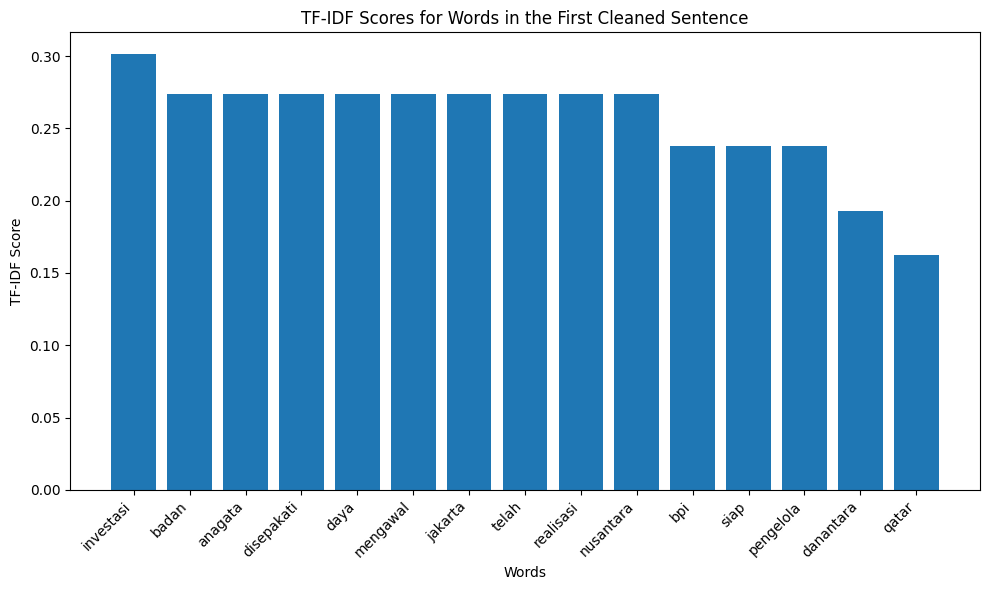


Top TF-IDF features in first sentence:
   Feature   TF-IDF
 investasi 0.301340
     badan 0.274034
   anagata 0.274034
disepakati 0.274034
      daya 0.274034
  mengawal 0.274034
   jakarta 0.274034
     telah 0.274034
 realisasi 0.274034
 nusantara 0.274034
       bpi 0.237952
      siap 0.237952
 pengelola 0.237952
 danantara 0.192495
     qatar 0.162553


In [5]:
# Helper function to get TF-IDF scores for a specific sentence
def get_tfidf_for_sentence(features, sentence_index, feature_names):
    sentence_tfidf = features[sentence_index].toarray()[0]
    tfidf_df = pd.DataFrame({'Feature': feature_names, 'TF-IDF': sentence_tfidf})
    tfidf_df = tfidf_df[tfidf_df['TF-IDF'] > 0].sort_values('TF-IDF', ascending=False)
    return tfidf_df

# Visualize TF-IDF scores for the first cleaned sentence
first_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)

plt.figure(figsize=(10, 6))
plt.bar(first_sentence_tfidf_df['Feature'], first_sentence_tfidf_df['TF-IDF'])
plt.xlabel("Words")
plt.ylabel("TF-IDF Score")
plt.title("TF-IDF Scores for Words in the First Cleaned Sentence")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop TF-IDF features in first sentence:")
print(first_sentence_tfidf_df.to_string(index=False))

# Calculate TF-IDF Score per Sentence

In [6]:
# Variable initialization
sent_scores = []

# Calculate average TF-IDF score per sentence
for i in features:
    sent_score = i.sum()
    sent_length = len(i.data)
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    sent_scores.append(avg_score)

# Threshold = average of all sentence scores
threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0
print("Threshold (Average of Sentence Scores):", threshold)

Threshold (Average of Sentence Scores): 0.2522570624731002


In [7]:
# Manual TF-IDF calculation for the word 'investasi'
def calculate_tf(term, document):
    words = word_tokenize(document.lower())
    return words.count(term) / len(words) if len(words) > 0 else 0

def calculate_idf(term, all_documents):
    num_docs_with_term = sum(1 for doc in all_documents if term.lower() in word_tokenize(doc.lower()))
    return math.log(len(all_documents) / num_docs_with_term) if num_docs_with_term > 0 else 0

target_word = 'investasi'
tfidf_scores = {}
for i, sent in enumerate(sent_token):
    cleaned_sent = stopword_remover.remove(sent)
    tf = calculate_tf(target_word, cleaned_sent)
    idf = calculate_idf(target_word, cleaned_sentences)
    tfidf_scores[f"Sentence {i+1}"] = tf * idf

print(f"TF-IDF Score for '{target_word}' in each sentence:")
for sent_num, score in tfidf_scores.items():
    print(f"{sent_num}: {score:.4f}")

overall_idf = calculate_idf(target_word, cleaned_sentences)
print(f"\nOverall IDF for '{target_word}': {overall_idf:.4f}")

# TF-IDF using sklearn for comparison
tfidf_col_index = list(feature_names).index(target_word) if target_word in feature_names else None
if tfidf_col_index is not None:
    print(f"\nTF-IDF Score for '{target_word}' using TfidfVectorizer:")
    for i, score in enumerate(features[:, tfidf_col_index].toarray().flatten()):
        print(f"Sentence {i+1}: {score:.4f}")

TF-IDF Score for 'investasi' in each sentence:
Sentence 1: 0.0762
Sentence 2: 0.0000
Sentence 3: 0.0331
Sentence 4: 0.0508
Sentence 5: 0.0000
Sentence 6: 0.0000
Sentence 7: 0.0000
Sentence 8: 0.0000
Sentence 9: 0.0293
Sentence 10: 0.0423
Sentence 11: 0.0000
Sentence 12: 0.0381
Sentence 13: 0.0000
Sentence 14: 0.0726
Sentence 15: 0.0000

Overall IDF for 'investasi': 0.7621

TF-IDF Score for 'investasi' using TfidfVectorizer:
Sentence 1: 0.3013
Sentence 2: 0.0000
Sentence 3: 0.1377
Sentence 4: 0.1661
Sentence 5: 0.0000
Sentence 6: 0.0000
Sentence 7: 0.0000
Sentence 8: 0.0000
Sentence 9: 0.1263
Sentence 10: 0.1653
Sentence 11: 0.0000
Sentence 12: 0.1481
Sentence 13: 0.0000
Sentence 14: 0.2966
Sentence 15: 0.0000


# Get Summary Sentences

In [8]:
# Final summary initialization
final_summ = ""

# Include sentences with score >= threshold
for index, data in enumerate(sent_scores):
    if data >= threshold:
        final_summ = final_summ + " " + sent_token[index]
        print("-", sent_token[index])

- Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar.
- Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.
- Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar.
- Presiden Prabowo menyampaikan masing-masing negara akan berkontribusi sebesar USD2 miliar dalam dana tersebut.
- Dana itu akan dikelola oleh BPI Danantara bersama dengan Qatar Investment Authority (QIA) dalam co-partnership.
- "Danantara Indonesia siap menjalankan mandat tersebut dengan menerapkan tata kelola investasi yang prudent, transparan, dan berorientasi pada hasil.
- Fokus kami adalah memastikan bahwa setiap proyek yang didanai memberikan dampak strategis dan berkelanjutan bagi perekonomian nasional," ujar Rosan.
- "Kemitraan ini merupakan langkah konkret dalam membangun kepercayaan dengan mitra global strate

# Summarization Result

In [9]:
final_summ

' Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar. Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha. Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar. Presiden Prabowo menyampaikan masing-masing negara akan berkontribusi sebesar USD2 miliar dalam dana tersebut. Dana itu akan dikelola oleh BPI Danantara bersama dengan Qatar Investment Authority (QIA) dalam co-partnership. "Danantara Indonesia siap menjalankan mandat tersebut dengan menerapkan tata kelola investasi yang prudent, transparan, dan berorientasi pada hasil. Fokus kami adalah memastikan bahwa setiap proyek yang didanai memberikan dampak strategis dan berkelanjutan bagi perekonomian nasional," ujar Rosan. "Kemitraan ini merupakan langkah konkret dalam membangun kepercayaan dengan mitra global strategis seperti Qa